# This is a file used to train a light weigt CNN to classify whether a component leg is plugged into the breadboard socket


In [ ]:
!git clone 'https://github.com/AlexMIaoPU/remote-lab.git'

Cloning into 'remote-lab'...
remote: Enumerating objects: 1417, done.
remote: Counting objects: 100% (736/736), done.
remote: Compressing objects: 100% (724/724), done.
remote: Total 1417 (delta 15), reused 730 (delta 12), pack-reused 681 (from 1)
Receiving objects: 100% (1417/1417), 162.71 MiB | 23.97 MiB/s, done.
Resolving deltas: 100% (40/40), done.


In [ ]:
!mv -v ./remote-lab/[!.]* ./

renamed './remote-lab/background.jpg' -> './background.jpg'
renamed './remote-lab/bb2.jpg' -> './bb2.jpg'
renamed './remote-lab/bb3.jpg' -> './bb3.jpg'
renamed './remote-lab/bb4.jpg' -> './bb4.jpg'
renamed './remote-lab/bb5.jpg' -> './bb5.jpg'
renamed './remote-lab/bb6.jpg' -> './bb6.jpg'
renamed './remote-lab/breadboard.jpg' -> './breadboard.jpg'
renamed './remote-lab/Classifier.py' -> './Classifier.py'
renamed './remote-lab/Colour_band_detection.ipynb' -> './Colour_band_detection.ipynb'
renamed './remote-lab/content.jpg' -> './content.jpg'
renamed './remote-lab/Copy_of_Detectron2_Tutorial.ipynb' -> './Copy_of_Detectron2_Tutorial.ipynb'
renamed './remote-lab/dataset' -> './dataset'
renamed './remote-lab/extracted_images' -> './extracted_images'
renamed './remote-lab/gird_extract.ipynb' -> './gird_extract.ipynb'
renamed './remote-lab/LossEvalHook.py' -> './LossEvalHook.py'
renamed './remote-lab/Mask.py' -> './Mask.py'
renamed './remote-lab/plug_classifier_mobilenet.pth' -> './plug_clas

## Setup

In [ ]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [ ]:
# === CONFIG ===
data_dir = "./plug_data"  # Folder with `plugged/` and `not_plugged/`
num_classes = 3 # plugged, not_plugged, pass_over
batch_size = 32
num_epochs = 30
learning_rate = 1e-5  # Lowered learning rate
input_size = 224  # MobilenetV2 expects 224x224 input

In [ ]:
# === DATA AUGMENTATION ===
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'infer': transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

In [ ]:
# === DATA LOADING ===
from collections import Counter

image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'val']
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=batch_size, shuffle=True, num_workers=2),
    'val': DataLoader(image_datasets['val'], batch_size=batch_size, shuffle=False, num_workers=2)
}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
import math
# === MODEL ===
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)
model = model.to(device)

# === LOSS & OPTIMIZER ===
# Calculate class weights based on inverse frequency
class_counts = Counter(image_datasets['train'].targets)
total_samples = len(image_datasets['train'])
#class_weights = torch.tensor(
#    [math.log(total_samples / class_counts[i], 2) for i in range(num_classes)],
#    dtype=torch.float32
#).to(device)

class_weights = torch.tensor(
    [0.1, 0.3, 0.7],
    dtype=torch.float32
).to(device)

for i, class_name in enumerate(class_names):
    print(f"Class '{class_name}' is assigned weight {class_weights[i]}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4) # Added weight decay

Class 'not_plugged' is assigned weight 0.10000000149011612
Class 'pass_over' is assigned weight 0.30000001192092896
Class 'plugged' is assigned weight 0.699999988079071


In [ ]:
# === TRAINING LOOP ===
def train_model(model, criterion, optimizer, num_epochs=10):
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 20)

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0

            all_preds = []
            all_labels = []

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == 'val':
                print(confusion_matrix(all_labels, all_preds))
                print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    return model

# Visualisation

In [ ]:
# === VISUAL VALIDATION ===
def visualize_predictions(model, dataset, num_images=6):
    model.eval()
    images_so_far = 0
    plt.figure(figsize=(12, 6))

    for i in range(num_images):
        idx = random.randint(0, len(dataset) - 1)
        image, label = dataset[idx]
        input_tensor = image.unsqueeze(0).to(device)
        output = model(input_tensor)
        _, pred = torch.max(output, 1)

        image_np = image.permute(1, 2, 0).cpu().numpy()
        image_np = np.clip(image_np, 0, 1) # denormalize

        plt.subplot(2, 3, i+1)
        plt.imshow(image_np)
        plt.title(f"GT: {class_names[label]}\nPred: {class_names[pred.item()]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# === INFERENCE ON UNSEEN DATA ===
def classify_single_image(model, image_path):
    model.eval()
    image = Image.open(image_path)
    transform = data_transforms['infer']
    input_tensor = transform(image).unsqueeze(0).to(device)
    output = model(input_tensor)
    probs = torch.softmax(output, dim=1)
    _, pred = torch.max(output, 1)
    return class_names[pred.item()], probs.squeeze().cpu().detach().numpy()

## Training and Save

In [ ]:
# === TRAIN ===
model = train_model(model, criterion, optimizer, num_epochs=num_epochs)

Epoch 1/30
--------------------
Train Loss: 1.0780 Acc: 0.3712
Val Loss: 1.0105 Acc: 0.5238
[[39  7 12]
 [17  5  7]
 [ 6  1 11]]
              precision    recall  f1-score   support

 not_plugged       0.63      0.67      0.65        58
   pass_over       0.38      0.17      0.24        29
     plugged       0.37      0.61      0.46        18

    accuracy                           0.52       105
   macro avg       0.46      0.49      0.45       105
weighted avg       0.52      0.52      0.50       105

Epoch 2/30
--------------------
Train Loss: 0.8739 Acc: 0.5383
Val Loss: 0.8996 Acc: 0.6095
[[36  5 17]
 [ 5 12 12]
 [ 2  0 16]]
              precision    recall  f1-score   support

 not_plugged       0.84      0.62      0.71        58
   pass_over       0.71      0.41      0.52        29
     plugged       0.36      0.89      0.51        18

    accuracy                           0.61       105
   macro avg       0.63      0.64      0.58       105
weighted avg       0.72      0.61  

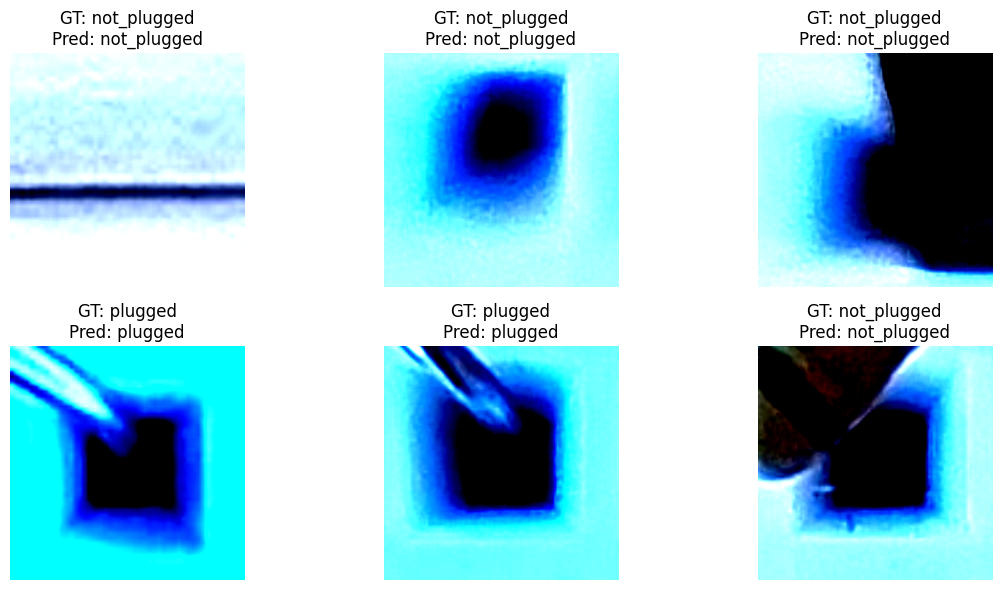

In [ ]:
# === VISUALIZE ===
visualize_predictions(model, image_datasets['val'])

In [ ]:
# === EXAMPLE USAGE ===
label, probabilities = classify_single_image(model, "./plug_data/test/snapshot_2403_1932_3_2.png")
print("Prediction:", label, "\nProbabilities:", probabilities)

Prediction: pass_over 
Probabilities: [0.01492584 0.88157225 0.10350192]


In [ ]:
# === SAVE ===
torch.save(model.state_dict(), "plug_classifier_mobilenet3.pth")